## Item Bank Diagnostics — Dimensional Coverage

In 2-D the synthetic bank spaces discrimination directions evenly over `[0, π)`, so coverage is guaranteed.  
In **d ≥ 3** directions are drawn uniformly at random from the unit sphere, so coverage can be uneven for a finite bank.

This notebook quantifies how well a bank covers all latent directions using the **total information matrix**

$$G = A^\top A, \qquad A \in \mathbb{R}^{n_{\text{items}} \times d}$$

where row $q$ of $A$ is item $q$'s discrimination vector $\mathbf{a}_q$.  
Each eigenvalue $\lambda_i$ of $G$ is the total squared discrimination along the $i$-th principal direction of the bank —
a small eigenvalue means that direction is barely probed.

**Key numbers to watch:**

| Quantity | Ideal value | Formula |
|---|---|---|
| All eigenvalues equal | $n_{\text{items}}/d$ | $\lambda_i = \text{tr}(G)/d$ |
| Condition number | close to 1 | $\kappa = \lambda_{\max}/\lambda_{\min}$ |
| Effective rank | $d$ | $(\sum\lambda_i)^2 / \sum\lambda_i^2$ |

### Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray


def find_repo_root(start: Path) -> Path:
    """Find the project root from either the repo root or notebooks/ directory."""
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "synthetic.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing src/synthetic.py")


repo_root = find_repo_root(Path.cwd().resolve())
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)

from src.synthetic import synthetic_item_bank
from src.plots import (
    ACTIVE_BLACK, PALETTE, POSTERIOR_GREEN, PRIOR_BLUE,
    QUESTION_ORANGE, STRUCTURE_GRAY,
    apply_notebook_style, style_ax,
)

apply_notebook_style()
print(f"Using repo root: {repo_root}")


Using repo root: C:\Users\49160\Adaptive-Onboarding


### Helpers

In [3]:
def discrimination_matrix(bank) -> NDArray[np.float64]:
    """Stack item discrimination vectors into an (n_items, d) matrix."""
    return np.stack([item.a for item in bank])  # (n_items, d)


def info_matrix(A: NDArray[np.float64]) -> NDArray[np.float64]:
    """G = A^T A  —  total bank information (d, d)."""
    return A.T @ A


def bank_diagnostics(bank) -> dict:
    """Return a dict of scalar summary statistics for an item bank."""
    A     = discrimination_matrix(bank)
    G     = info_matrix(A)
    eigs  = np.linalg.eigvalsh(G)          # ascending order
    lam_max, lam_min = eigs[-1], eigs[0]
    n, d  = A.shape
    return {
        "n_items":       n,
        "dim":           d,
        "eigenvalues":   eigs,
        "lam_min":       float(lam_min),
        "lam_max":       float(lam_max),
        "condition":     float(lam_max / lam_min) if lam_min > 0 else np.inf,
        "effective_rank":float(eigs.sum()**2 / (eigs**2).sum()),
        "per_axis_info": np.diag(G),       # G_ii = sum_q a_{q,i}^2
        "A":             A,
        "G":             G,
    }


print("Helpers ready.")

Helpers ready.


---
## 1 — Eigenvalue spectrum for one bank

Change `DIM` and `N_ITEMS` to match your experiment configuration.

In [4]:
DIM     = 6
N_ITEMS = 50
SEED    = 29

bank = synthetic_item_bank(n_items=N_ITEMS, dim=DIM, n_categories=4, rng_seed=SEED)
diag = bank_diagnostics(bank)

print(f"Bank: {diag['n_items']} items, {diag['dim']}D")
print(f"Eigenvalues (ascending): {np.round(diag['eigenvalues'], 3)}")
print(f"Expected (uniform):      {diag['n_items'] / diag['dim']:.3f}  (= n_items / d)")
print(f"Condition number:        {diag['condition']:.2f}")
print(f"Effective rank:          {diag['effective_rank']:.2f}  (ideal = {diag['dim']})")

Bank: 50 items, 6D
Eigenvalues (ascending): [ 5.265  6.73   7.019  8.794  9.824 12.368]
Expected (uniform):      8.333  (= n_items / d)
Condition number:        2.35
Effective rank:          5.57  (ideal = 6)


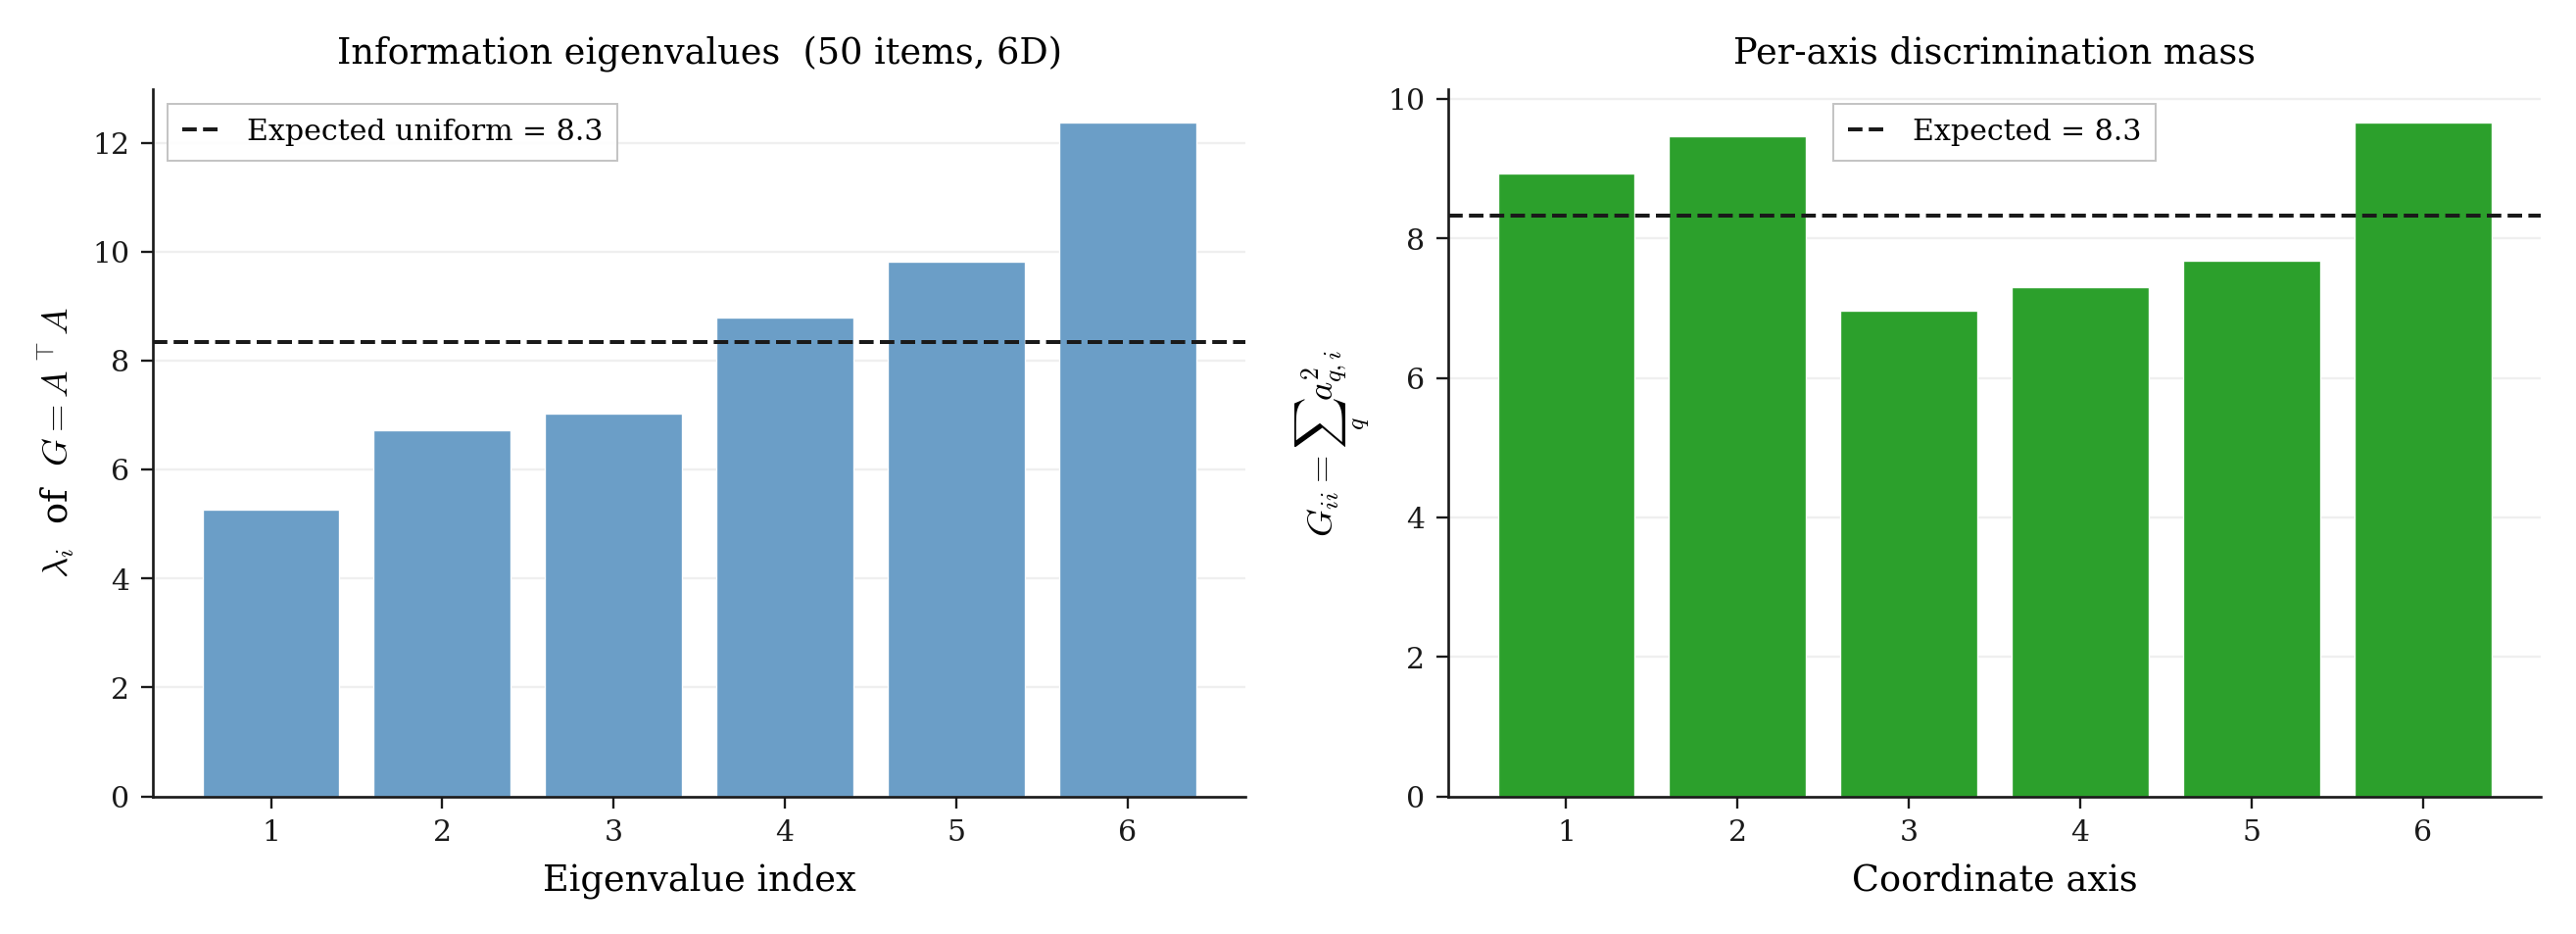

In [5]:
# ── Figure 1: Eigenvalue spectrum ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: bar chart of eigenvalues
ax = axes[0]
eigs = diag["eigenvalues"]
expected = diag["n_items"] / diag["dim"]
colors = [QUESTION_ORANGE if e < 0.5 * expected else PRIOR_BLUE for e in eigs]
ax.bar(range(1, len(eigs) + 1), eigs, color=colors, edgecolor="white", linewidth=0.4)
ax.axhline(expected, color=ACTIVE_BLACK, ls="--", linewidth=1.2,
           label=f"Expected uniform = {expected:.1f}")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel(r"$\lambda_i$  of  $G = A^\top A$")
ax.set_title(f"Information eigenvalues  ({N_ITEMS} items, {DIM}D)")
style_ax(ax, grid_axis="y")
ax.legend()

# Right: per-axis diagonal of G  (how much each coordinate axis is probed)
ax = axes[1]
axis_info = diag["per_axis_info"]
ax.bar(range(1, DIM + 1), axis_info, color=POSTERIOR_GREEN, edgecolor="white", linewidth=0.4)
ax.axhline(expected, color=ACTIVE_BLACK, ls="--", linewidth=1.2,
           label=f"Expected = {expected:.1f}")
ax.set_xlabel("Coordinate axis")
ax.set_ylabel(r"$G_{ii} = \sum_q a_{q,i}^2$")
ax.set_title("Per-axis discrimination mass")
style_ax(ax, grid_axis="y")
ax.legend()

plt.tight_layout()
plt.show()

---
## 2 — Pairwise projection scatter

Each dot is one item's discrimination vector projected onto a pair of axes.  
A good bank fills each 2D panel roughly uniformly; clustering in one quadrant means those two axes are coupled.

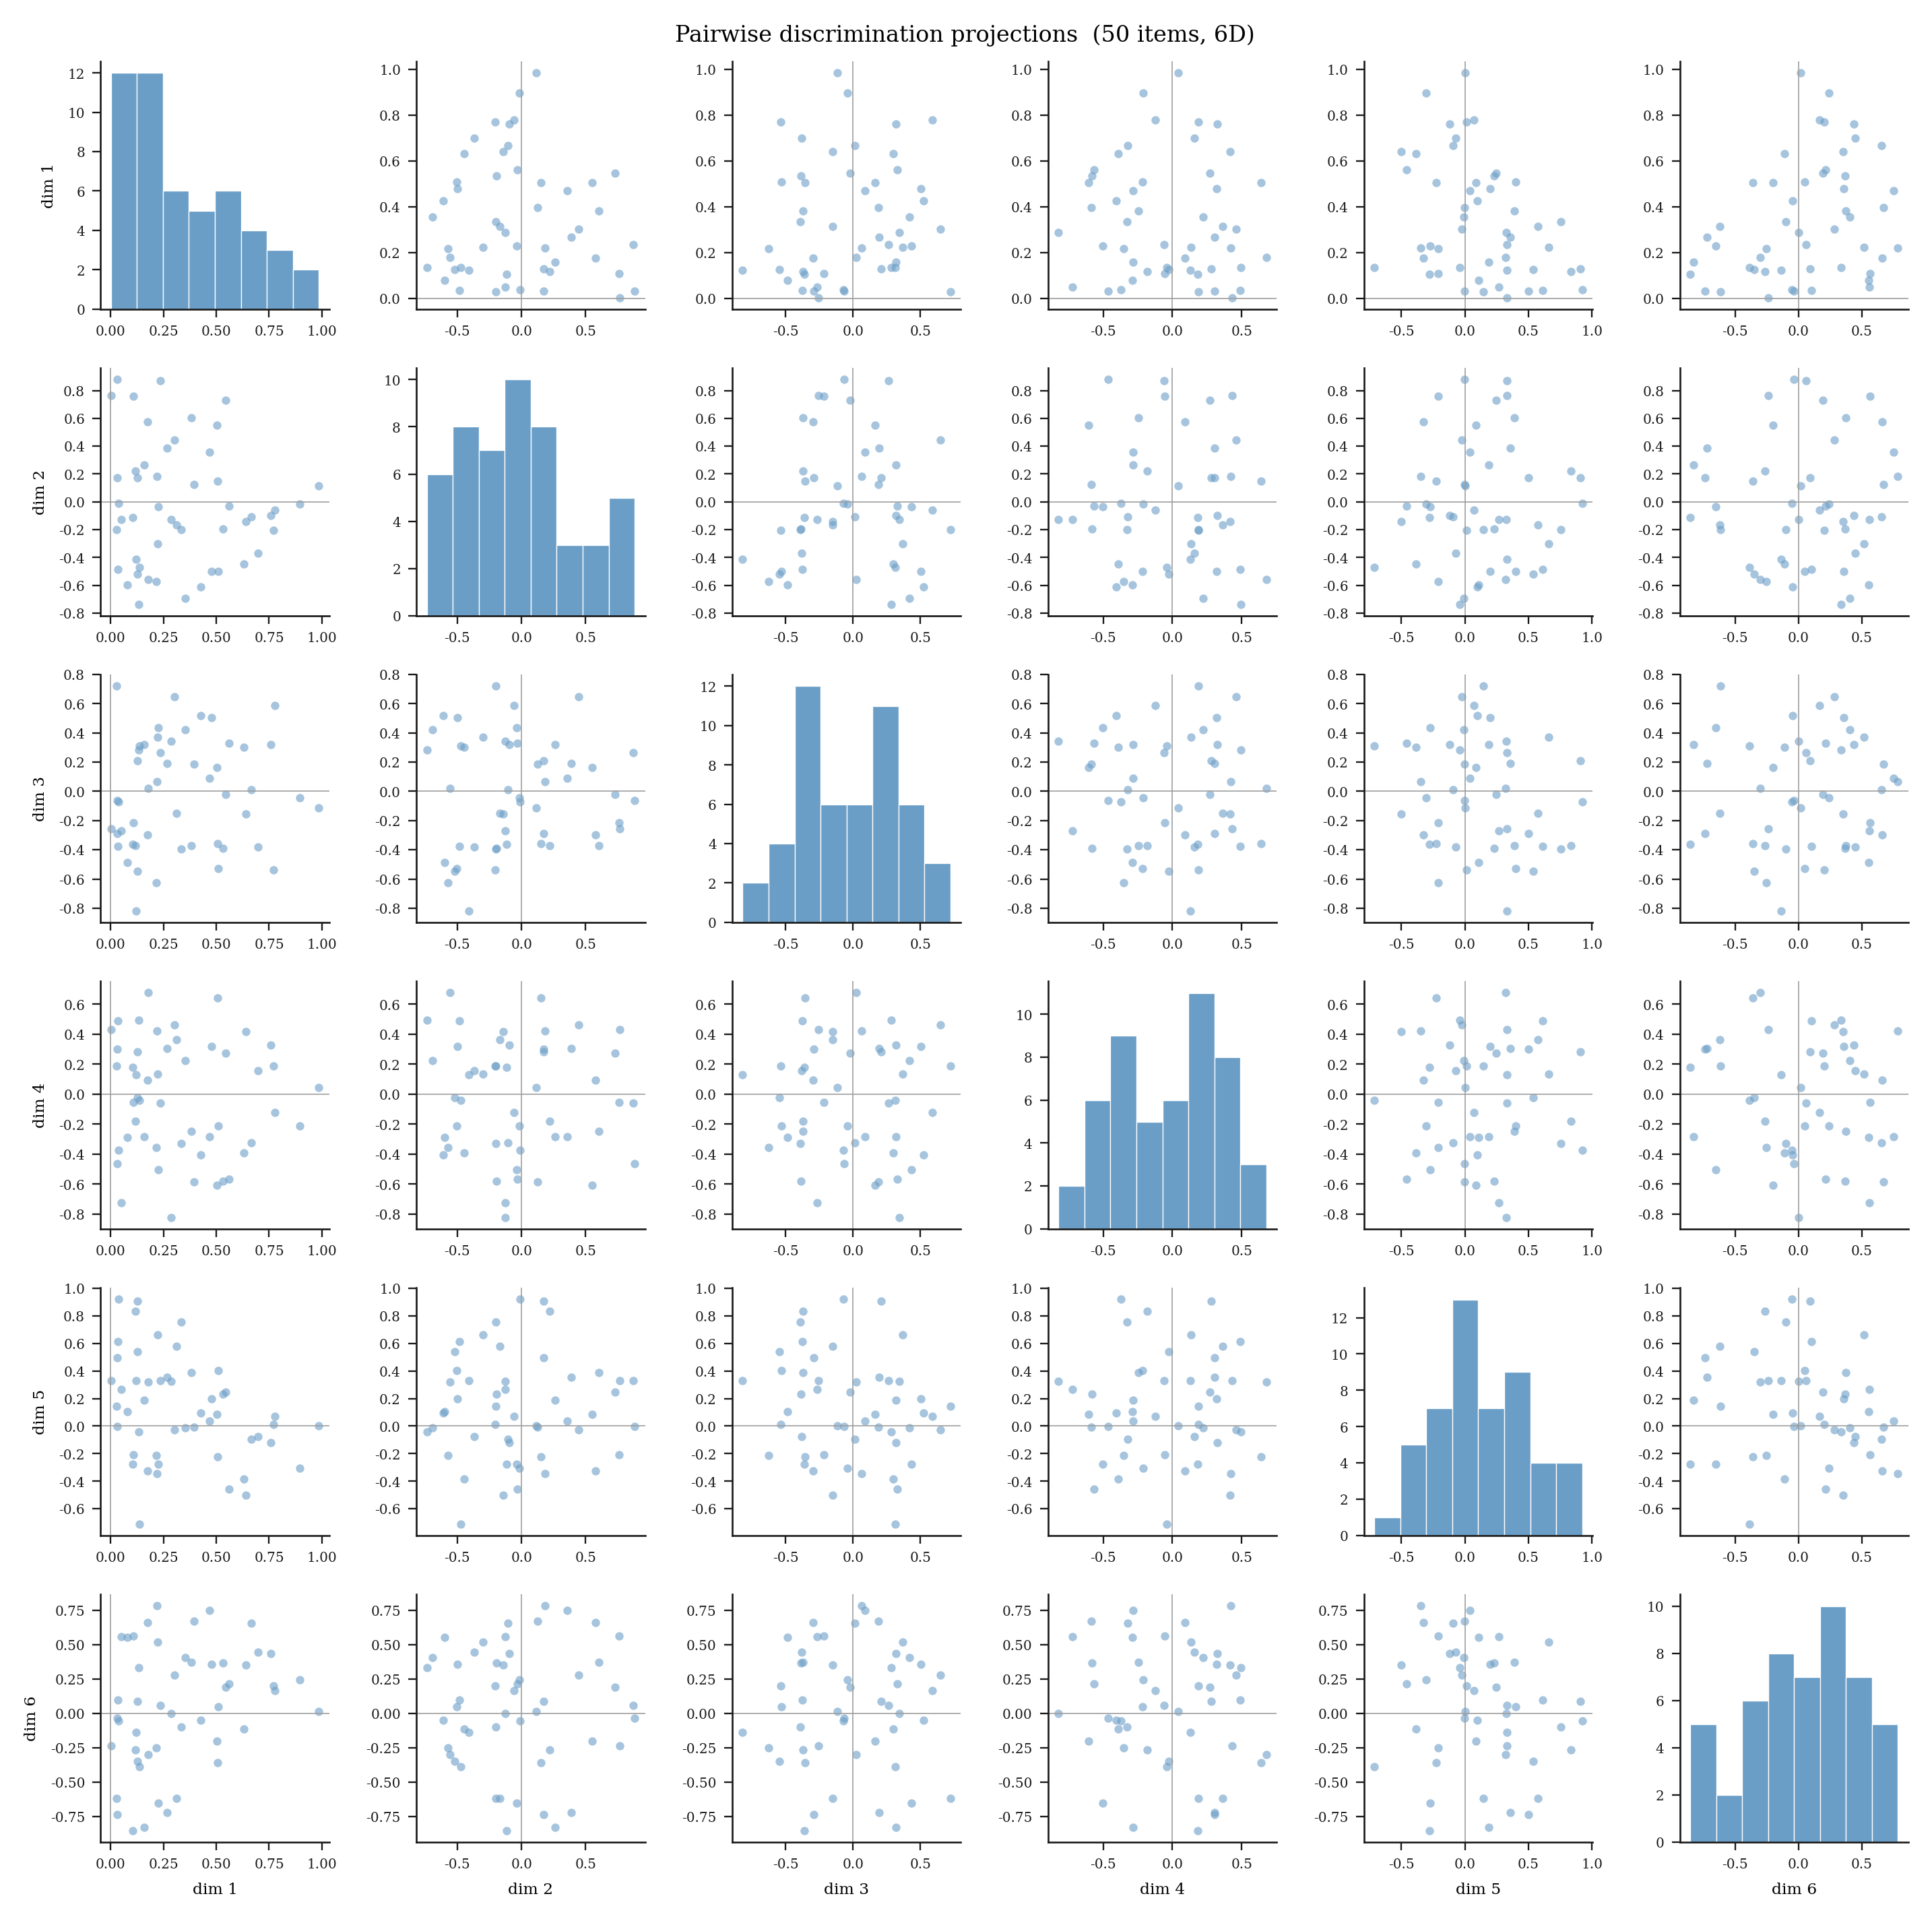

In [6]:
# ── Figure 2: Pairwise scatter of a-vector components ─────────────────────
A   = diag["A"]
d   = diag["dim"]
fig, axes = plt.subplots(d, d, figsize=(2 * d, 2 * d))

for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        if i == j:
            ax.hist(A[:, i], bins=8, color=PRIOR_BLUE, edgecolor="white", linewidth=0.4)
        else:
            ax.scatter(A[:, j], A[:, i], s=14, color=PRIOR_BLUE, alpha=0.6, linewidths=0)
            ax.axhline(0, color=STRUCTURE_GRAY, linewidth=0.5)
            ax.axvline(0, color=STRUCTURE_GRAY, linewidth=0.5)
        if i == d - 1:
            ax.set_xlabel(f"dim {j+1}", fontsize=7)
        if j == 0:
            ax.set_ylabel(f"dim {i+1}", fontsize=7)
        ax.tick_params(labelsize=6)

fig.suptitle(f"Pairwise discrimination projections  ({N_ITEMS} items, {DIM}D)", fontsize=10)
plt.tight_layout()
plt.show()

---
## 3 — Condition number across seeds

Because directions are random, the condition number varies by seed.  
This cell runs `N_SEEDS` replications to show the full distribution.

In [7]:
N_SEEDS = 200

conds, eff_ranks = [], []
for s in range(N_SEEDS):
    b = synthetic_item_bank(n_items=N_ITEMS, dim=DIM, n_categories=4, rng_seed=s)
    d_ = bank_diagnostics(b)
    conds.append(d_["condition"])
    eff_ranks.append(d_["effective_rank"])

print(f"Condition number  — median {np.median(conds):.2f},  "
      f"90th pct {np.percentile(conds, 90):.2f},  max {max(conds):.2f}")
print(f"Effective rank    — median {np.median(eff_ranks):.2f}  (ideal = {DIM})")

Condition number  — median 2.58,  90th pct 3.20,  max 3.86
Effective rank    — median 5.47  (ideal = 6)


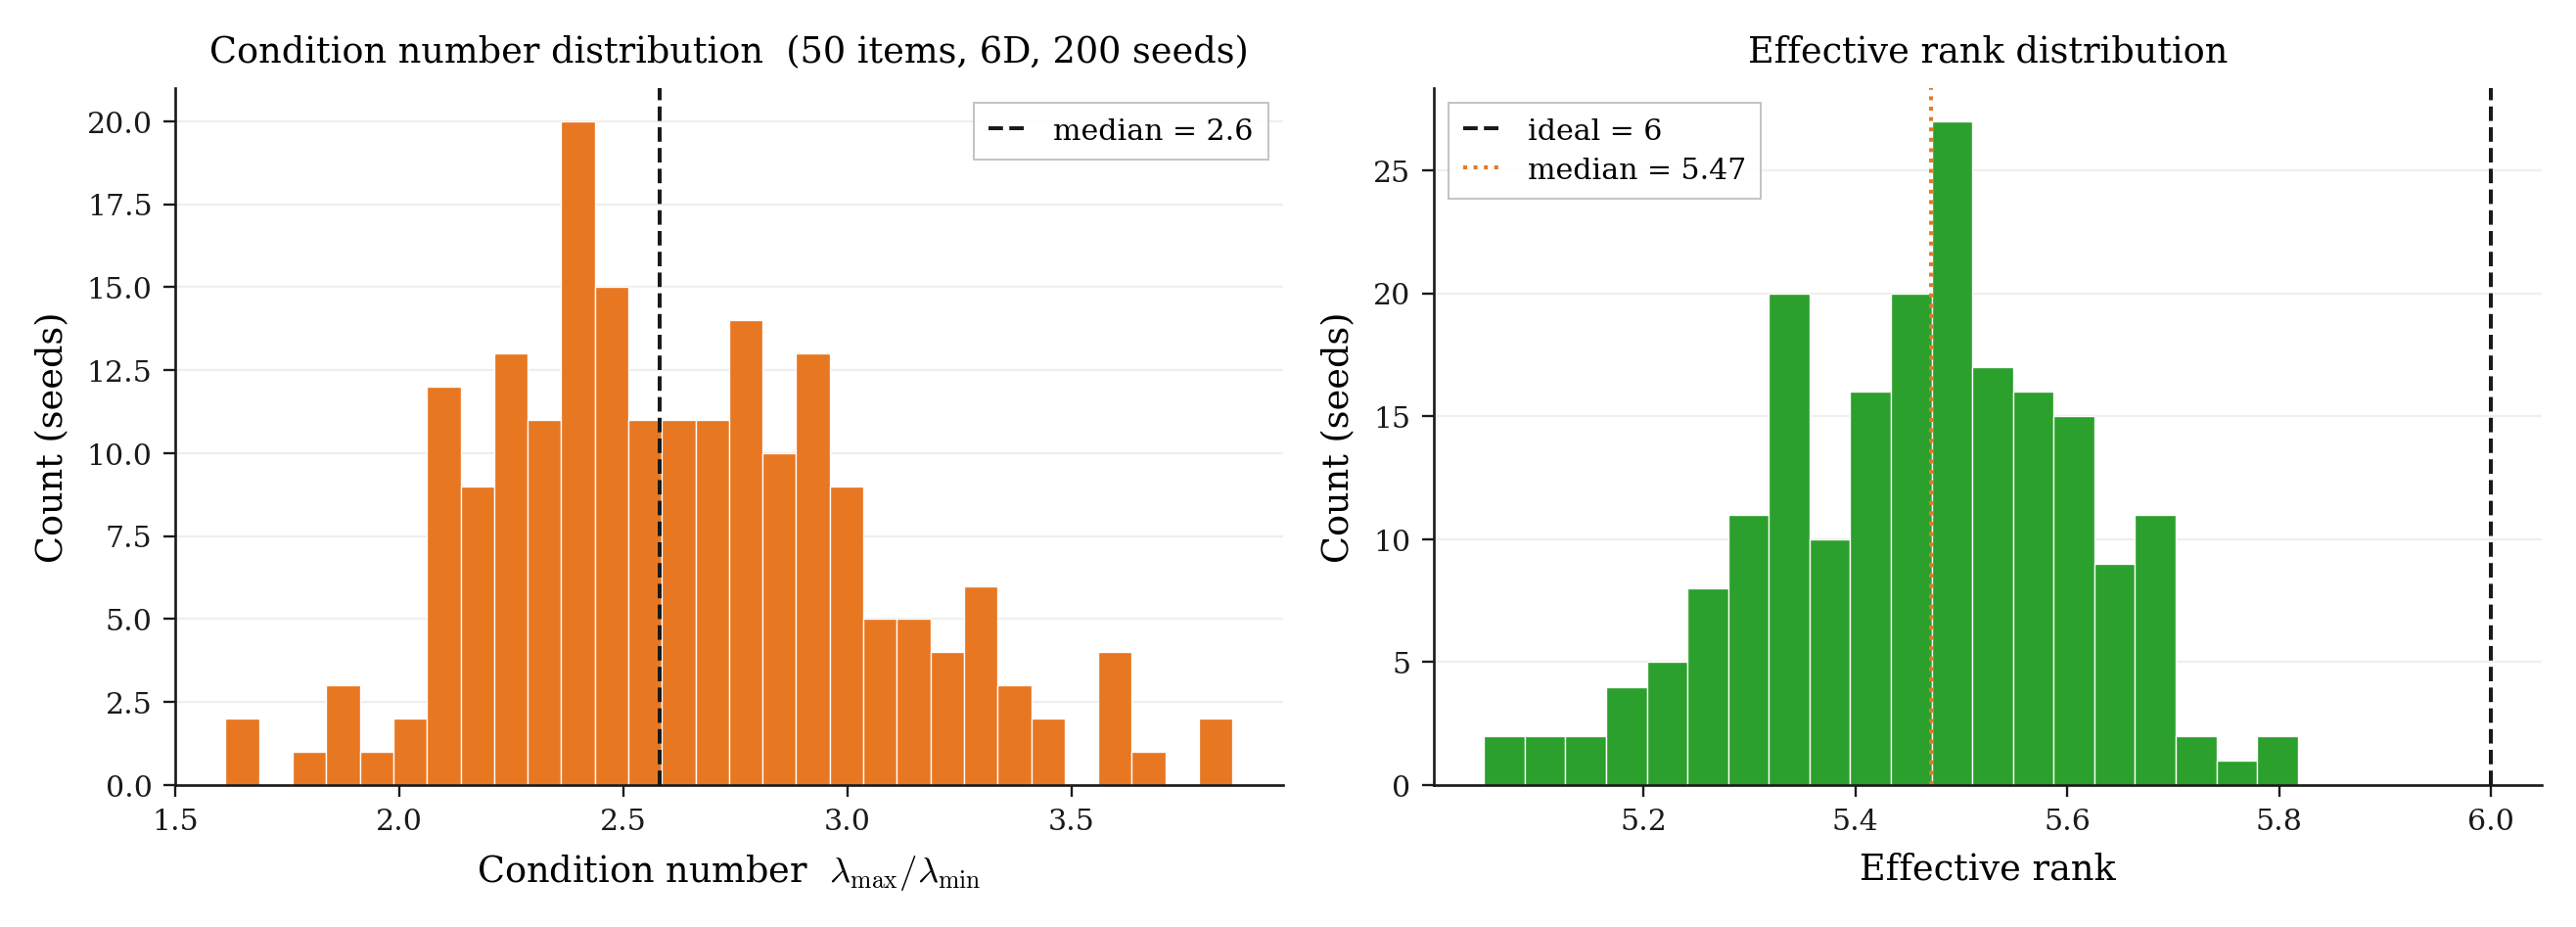

In [8]:
# ── Figure 3: Distribution of condition number over seeds ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(conds, bins=30, color=QUESTION_ORANGE, edgecolor="white", linewidth=0.4)
ax.axvline(np.median(conds), color=ACTIVE_BLACK, ls="--", linewidth=1.2,
           label=f"median = {np.median(conds):.1f}")
ax.set_xlabel(r"Condition number  $\lambda_{\max}/\lambda_{\min}$")
ax.set_ylabel("Count (seeds)")
ax.set_title(f"Condition number distribution  ({N_ITEMS} items, {DIM}D, {N_SEEDS} seeds)")
style_ax(ax, grid_axis="y")
ax.legend()

ax = axes[1]
ax.hist(eff_ranks, bins=20, color=POSTERIOR_GREEN, edgecolor="white", linewidth=0.4)
ax.axvline(DIM, color=ACTIVE_BLACK, ls="--", linewidth=1.2, label=f"ideal = {DIM}")
ax.axvline(np.median(eff_ranks), color=QUESTION_ORANGE, ls=":", linewidth=1.2,
           label=f"median = {np.median(eff_ranks):.2f}")
ax.set_xlabel("Effective rank")
ax.set_ylabel("Count (seeds)")
ax.set_title("Effective rank distribution")
style_ax(ax, grid_axis="y")
ax.legend()

plt.tight_layout()
plt.show()

---
## 4 — Items needed for target condition number

How many items does it take to reliably keep the condition number below some target (e.g. < 5)?  
Sweeps `n_items` and plots the median and 90th-percentile condition number.

In [9]:
ITEM_COUNTS  = [10, 20, 30, 40, 50, 75, 100]
N_SEEDS_SCAN = 100   # seeds per item count  (lower for speed)
KAPPA_TARGET = 5.0

medians, p90s, pct_ok = [], [], []

for n in ITEM_COUNTS:
    ks = []
    for s in range(N_SEEDS_SCAN):
        b  = synthetic_item_bank(n_items=n, dim=DIM, n_categories=4, rng_seed=s)
        d_ = bank_diagnostics(b)
        ks.append(d_["condition"])
    medians.append(np.median(ks))
    p90s.append(np.percentile(ks, 90))
    pct_ok.append(np.mean(np.array(ks) < KAPPA_TARGET) * 100)
    print(f"  n={n:4d}:  median κ = {medians[-1]:.2f},  90th = {p90s[-1]:.2f},  "
          f"P(κ < {KAPPA_TARGET}) = {pct_ok[-1]:.0f}%")

  n=  10:  median κ = 15.32,  90th = 42.46,  P(κ < 5.0) = 2%
  n=  20:  median κ = 5.37,  90th = 8.87,  P(κ < 5.0) = 40%
  n=  30:  median κ = 3.68,  90th = 4.94,  P(κ < 5.0) = 90%
  n=  40:  median κ = 2.87,  90th = 3.79,  P(κ < 5.0) = 100%
  n=  50:  median κ = 2.61,  90th = 3.27,  P(κ < 5.0) = 100%
  n=  75:  median κ = 2.17,  90th = 2.58,  P(κ < 5.0) = 100%
  n= 100:  median κ = 1.94,  90th = 2.26,  P(κ < 5.0) = 100%


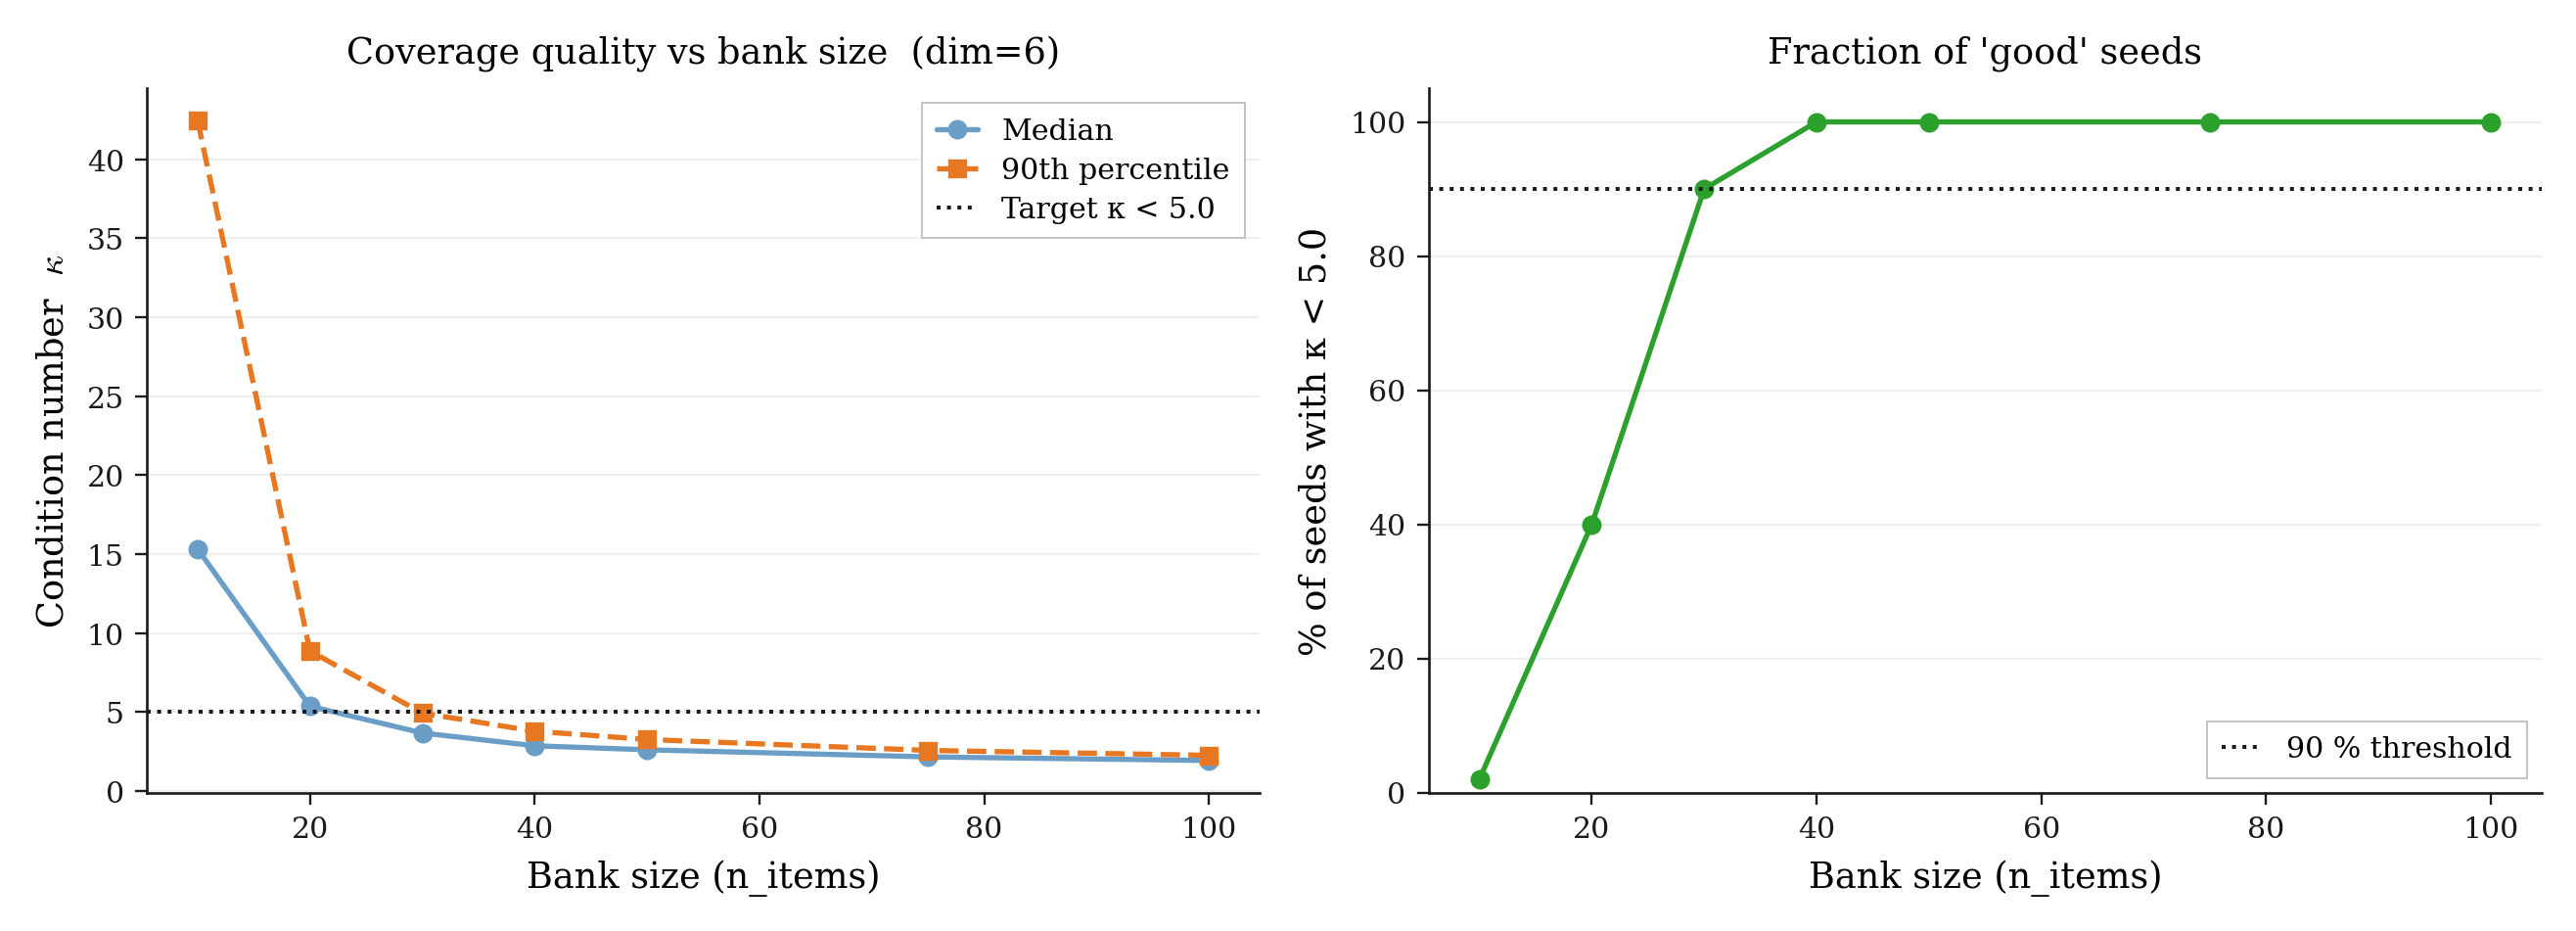

In [10]:
# ── Figure 4: Condition number vs bank size ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(ITEM_COUNTS, medians, color=PRIOR_BLUE,      ls="-",  marker="o", markersize=5,
        linewidth=1.6, label="Median")
ax.plot(ITEM_COUNTS, p90s,    color=QUESTION_ORANGE, ls="--", marker="s", markersize=5,
        linewidth=1.6, label="90th percentile")
ax.axhline(KAPPA_TARGET, color=ACTIVE_BLACK, ls=":", linewidth=1.2,
           label=f"Target κ < {KAPPA_TARGET}")
ax.set_xlabel("Bank size (n_items)")
ax.set_ylabel(r"Condition number  $\kappa$")
ax.set_title(f"Coverage quality vs bank size  (dim={DIM})")
style_ax(ax, grid_axis="y")
ax.legend()

ax = axes[1]
ax.plot(ITEM_COUNTS, pct_ok, color=POSTERIOR_GREEN, ls="-", marker="o",
        markersize=5, linewidth=1.6)
ax.axhline(90, color=ACTIVE_BLACK, ls=":", linewidth=1.2, label="90 % threshold")
ax.set_xlabel("Bank size (n_items)")
ax.set_ylabel(f"% of seeds with κ < {KAPPA_TARGET}")
ax.set_title("Fraction of 'good' seeds")
ax.set_ylim(0, 105)
style_ax(ax, grid_axis="y")
ax.legend()

plt.tight_layout()
plt.show()

---
## 5 — Seed selection: pick the most isotropic bank

If a single run already shows a bad condition number, try a handful of seeds and pick the most isotropic one.  
This cell scans `CANDIDATE_SEEDS` and reports the best one — plug it into your experiment scripts via `--seed-bank`.

In [11]:
CANDIDATE_SEEDS = range(50)

results = []
for s in CANDIDATE_SEEDS:
    b  = synthetic_item_bank(n_items=N_ITEMS, dim=DIM, n_categories=4, rng_seed=s)
    d_ = bank_diagnostics(b)
    results.append((s, d_["condition"], d_["effective_rank"]))

results.sort(key=lambda r: r[1])  # sort by condition number ascending

print(f"{'Seed':>6}  {'κ':>8}  {'eff. rank':>10}")
print("-" * 28)
for seed, kappa, eff_rank in results[:10]:
    print(f"{seed:6d}  {kappa:8.2f}  {eff_rank:10.2f}")

best_seed = results[0][0]
print(f"\nBest seed: {best_seed}  (κ = {results[0][1]:.2f})")
print(f"  → use: python -m experiments.policy_comparison --seed-bank {best_seed}")

  Seed         κ   eff. rank
----------------------------
     2      1.81        5.75
    44      1.99        5.61
    41      2.06        5.56
    17      2.06        5.67
     0      2.10        5.53
    16      2.11        5.70
     1      2.11        5.54
    26      2.17        5.69
    15      2.21        5.47
    14      2.25        5.67

Best seed: 2  (κ = 1.81)
  → use: python -m experiments.policy_comparison --seed-bank 2


---
## Notes

_Record observations here after running the cells._

### Condition number at default config (6D, 30 items, seed 0)

- 

### Minimum bank size to reliably achieve κ < 5

- 

### Chosen seed for sweep experiments

- 